### [ 부스팅(Boosting) 3개 모델 비교 ]
- **비교 대상**
    - AdaBoostClassifier
    - GradientBoostingClassifier
    - HistGradientBoostingClassifier

- **데이터셋**
    - load_digits (손글씨 숫자, 전체 1,797개 x 64픽셀, 10클래스)

- **기본값은 500개로 설정** 
    - GridSearchCV는 폴드 수 x 파라미터조합 수만큼 반복 학습하기 때문
    - 전체 1,797개로 돌리면 컴퓨터 성능에 따라 수 분 이상 걸릴 수 있음.


- **[0] 모듈 로딩 및 전역변수 설정**

In [1]:
## 데이터 분석 관련
import time
import numpy as np
import pandas as pd

## 데이터 시각화 관련
import matplotlib.pyplot as plt
import koreanize_matplotlib

## ML 데이터 관련
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

## ML 교차검증 및 튜닝 관련
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score, GridSearchCV

## ML 전처리 관련
from sklearn.preprocessing import RobustScaler

## ML 파이프라인 & 성능지표 관련
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

## ML 모델 관련
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier


In [2]:
## -------------------------------------------
## 전역변수
## -------------------------------------------
RANDOM_STATE = 42


- **[2] 데이터 로딩 및 데이터 수 설정**

In [ ]:
## ---------------------------------------
## 데이터 로딩
## ---------------------------------------
digits = load_digits()
X, y = digits.data, digits.target

print('전체 데이터 크기:', X.shape)
print('클래스 종류:', np.unique(y))


전체 데이터 크기: (1797, 64)
클래스 종류: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
## --------------------------------------------------------------------------
## 데이터 크기 조절 (속도 vs 정확도 트레이드오프)
## - SAMPLE_SIZE를 바꿔서 실행 시간이 어떻게 달라지는지 직접 확인
## - 500 → 결과를 빠르게 확인
## - None → 전체 1,797개 사용 (정확도는 더 안정적이지만 GridSearchCV는 오래 걸림)
## --------------------------------------------------------------------------
SAMPLE_SIZE = 500   # None = 전체(1,797개) 사용

## 데이터 수 설정에 따른 데이터 추출 
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(X):
    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(X), size=SAMPLE_SIZE, replace=False)
    X_sample, y_sample = X[idx], y[idx]
else:
    X_sample, y_sample = X, y

print(f'사용 데이터 크기: {X_sample.shape[0]}개')


사용 데이터 크기: 500개


- **[3] 데이터셋 준비**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, 
    y_sample, 
    test_size=0.2, 
    stratify=y_sample, 
    random_state=RANDOM_STATE
)

print(f'[TRAIN] : {X_train.shape}, {y_train.shape}')
print(f'[TEST ] : {X_test.shape}, {y_test.shape}')


[TRAIN] : (400, 64), (400,)
[TEST ] : (100, 64), (100,)


- **[4] 기본 비교 (하이퍼파라미터 튜닝 없음)**
    - 기본 파라미터로 3개 모델의 정확도와 학습 시간을 먼저 비교


In [5]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

base_models = {
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

base_results = []
for name, model in base_models.items():
    t0 = time.time()
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    elapsed = time.time() - t0
    base_results.append({'모델': name, '평균 정확도': scores.mean(), '표준편차': scores.std(), '소요시간(s)': elapsed})
    print(f'{name:25s} acc={scores.mean():.4f} (+/-{scores.std():.4f})  time={elapsed:.2f}s')

base_df = pd.DataFrame(base_results)
base_df


AdaBoost                  acc=0.6577 (+/-0.0785)  time=0.35s


GradientBoosting          acc=0.8900 (+/-0.0249)  time=6.38s


HistGradientBoosting      acc=0.9050 (+/-0.0140)  time=2.76s


,모델,평균 정확도,표준편차,소요시간(s)
0,AdaBoost,0.657745,0.078505,0.346346
1,GradientBoosting,0.889986,0.024866,6.382231
2,HistGradientBoosting,0.905024,0.013996,2.762486


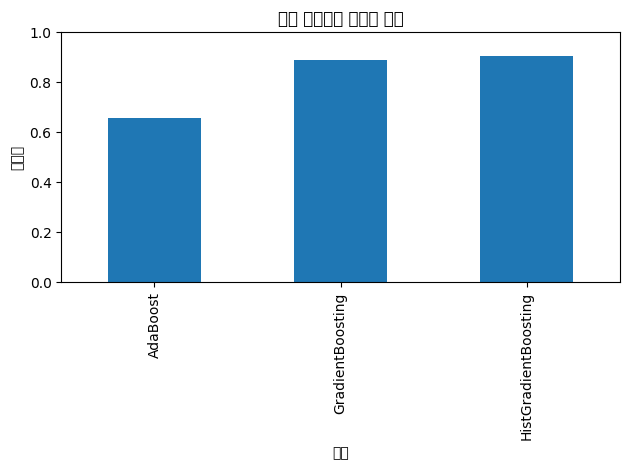

In [6]:
base_df.plot(x='모델', y=['평균 정확도'], kind='bar', legend=False, title='기본 파라미터 정확도 비교', ylim=(0,1))
plt.ylabel('정확도')
plt.tight_layout()
plt.show()


- **[5] GridSearchCV를 통한 하이퍼파라미터 튜닝**
    - 각 모델별로 주요 하이퍼파라미터를 GridSearchCV로 탐색
    - 파라미터 조합 수를 의도적으로 작게 잡아 실습 시간을 줄였음.


>> [5-1] AdaBoost 튜닝

In [7]:
ada_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.5, 1.0],
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(random_state=RANDOM_STATE),
    param_grid=ada_param_grid,
    cv=cv,
    scoring='accuracy',
)

t0 = time.time()
ada_grid.fit(X_train, y_train)
print(f'GridSearchCV 소요시간: {time.time()-t0:.2f}s')
print('Best params:', ada_grid.best_params_)
print('Best CV accuracy:', ada_grid.best_score_)


GridSearchCV 소요시간: 2.25s
Best params: {'learning_rate': 1.0, 'n_estimators': 100}
Best CV accuracy: 0.7125462911008865


>> 5-2. GradientBoosting 튜닝

In [8]:
gb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3],
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=gb_param_grid,
    cv=cv,
    scoring='accuracy',
)

t0 = time.time()
gb_grid.fit(X_train, y_train)
print(f'GridSearchCV 소요시간: {time.time()-t0:.2f}s')
print('Best params:', gb_grid.best_params_)
print('Best CV accuracy:', gb_grid.best_score_)


GridSearchCV 소요시간: 17.71s
Best params: {'max_depth': 2, 'n_estimators': 100}
Best CV accuracy: 0.8924924250925822


>> 5-3. HistGradientBoosting 튜닝

In [9]:
hgb_param_grid = {
    'max_iter': [50, 100],
    'max_depth': [None, 5],
}

hgb_grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=hgb_param_grid,
    cv=cv,
    scoring='accuracy',
)

t0 = time.time()
hgb_grid.fit(X_train, y_train)
print(f'GridSearchCV 소요시간: {time.time()-t0:.2f}s')
print('Best params:', hgb_grid.best_params_)
print('Best CV accuracy:', hgb_grid.best_score_)


GridSearchCV 소요시간: 9.78s
Best params: {'max_depth': 5, 'max_iter': 100}
Best CV accuracy: 0.9100362847417051


>> 5-4. 튜닝 결과 종합 비교

In [10]:
tuned_results = pd.DataFrame([
    {'모델': 'AdaBoost', 'Best CV 정확도': ada_grid.best_score_, 'Best Params': ada_grid.best_params_},
    {'모델': 'GradientBoosting', 'Best CV 정확도': gb_grid.best_score_, 'Best Params': gb_grid.best_params_},
    {'모델': 'HistGradientBoosting', 'Best CV 정확도': hgb_grid.best_score_, 'Best Params': hgb_grid.best_params_},
])
tuned_results


,모델,Best CV 정확도,Best Params
0,AdaBoost,0.712546,"{'learning_rate': 1.0, 'n_estimators': 100}"
1,GradientBoosting,0.892492,"{'max_depth': 2, 'n_estimators': 100}"
2,HistGradientBoosting,0.910036,"{'max_depth': 5, 'max_iter': 100}"


In [ ]:
## ------------------------------------
## 테스트셋 최종 평가
## ------------------------------------
for name, grid in [('AdaBoost', ada_grid), ('GradientBoosting', gb_grid), ('HistGradientBoosting', hgb_grid)]:
    pred = grid.best_estimator_.predict(X_test)
    print(f'{name:25s} Test Accuracy = {accuracy_score(y_test, pred):.4f}')


AdaBoost                  Test Accuracy = 0.8000
GradientBoosting          Test Accuracy = 0.9200
HistGradientBoosting      Test Accuracy = 0.9400


- **[6] Pipeline + GridSearchCV**
    - Pipeline(스케일러(RobustScaler)와 모델) + GridSearchCV 적용
    - Cross Validation 폴드마다 스케일러가 train 데이터에만 fit되어
    - data leakage(데이터 누출)를 막을 수 있음
    - ★ 파라미터 키 : '스텝이름__파라미터명' 형식


>> 5-1. AdaBoost Pipeline

In [12]:
ada_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('model', AdaBoostClassifier(random_state=RANDOM_STATE)),
])

ada_pipe_grid = {
    'model__n_estimators': [50, 100],
    'model__learning_rate': [0.5, 1.0],
}

ada_pipe_search = GridSearchCV(ada_pipe, param_grid=ada_pipe_grid, cv=cv, scoring='accuracy')

t0 = time.time()
ada_pipe_search.fit(X_train, y_train)
print(f'소요시간: {time.time()-t0:.2f}s')
print('Best params:', ada_pipe_search.best_params_)
print('Best CV accuracy:', ada_pipe_search.best_score_)


소요시간: 2.29s
Best params: {'model__learning_rate': 1.0, 'model__n_estimators': 100}
Best CV accuracy: 0.7125462911008865


>> 6-2. GradientBoosting Pipeline

In [13]:
gb_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('model', GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

gb_pipe_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [2, 3],
}

gb_pipe_search = GridSearchCV(gb_pipe, param_grid=gb_pipe_grid, cv=cv, scoring='accuracy')

t0 = time.time()
gb_pipe_search.fit(X_train, y_train)
print(f'소요시간: {time.time()-t0:.2f}s')
print('Best params:', gb_pipe_search.best_params_)
print('Best CV accuracy:', gb_pipe_search.best_score_)


소요시간: 18.05s
Best params: {'model__max_depth': 2, 'model__n_estimators': 100}
Best CV accuracy: 0.8924924250925822


>> 6-3. HistGradientBoosting Pipeline

In [14]:
hgb_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('model', HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])

hgb_pipe_grid = {
    'model__max_iter': [50, 100],
    'model__max_depth': [None, 5],
}

hgb_pipe_search = GridSearchCV(hgb_pipe, param_grid=hgb_pipe_grid, cv=cv, scoring='accuracy')

t0 = time.time()
hgb_pipe_search.fit(X_train, y_train)
print(f'소요시간: {time.time()-t0:.2f}s')
print('Best params:', hgb_pipe_search.best_params_)
print('Best CV accuracy:', hgb_pipe_search.best_score_)


소요시간: 9.90s
Best params: {'model__max_depth': 5, 'model__max_iter': 100}
Best CV accuracy: 0.9100362847417051


>> 6-4. Pipeline 결과 종합 + 최종 테스트 평가

In [15]:
pipe_results = pd.DataFrame([
    {'모델': 'AdaBoost (Pipeline)', 'Best CV 정확도': ada_pipe_search.best_score_},
    {'모델': 'GradientBoosting (Pipeline)', 'Best CV 정확도': gb_pipe_search.best_score_},
    {'모델': 'HistGradientBoosting (Pipeline)', 'Best CV 정확도': hgb_pipe_search.best_score_},
])
pipe_results


,모델,Best CV 정확도
0,AdaBoost (Pipeline),0.712546
1,GradientBoosting (Pipeline),0.892492
2,HistGradientBoosting (Pipeline),0.910036


In [16]:
for name, search in [('AdaBoost', ada_pipe_search), ('GradientBoosting', gb_pipe_search), ('HistGradientBoosting', hgb_pipe_search)]:
    pred = search.best_estimator_.predict(X_test)
    print(f'{name:25s} Test Accuracy = {accuracy_score(y_test, pred):.4f}')


AdaBoost                  Test Accuracy = 0.8000
GradientBoosting          Test Accuracy = 0.9200
HistGradientBoosting      Test Accuracy = 0.9400


<hr>
#### 전체 결과 요약 

| 단계 | 설명 |
|---|---|
| 3. 기본 비교 | 튜닝 없이 기본 파라미터로 정확도/속도 비교 |
| 4. GridSearchCV | 모델별 하이퍼파라미터 최적화 |
| 5. Pipeline + GridSearchCV | 스케일러를 포함해 data leakage 없이 튜닝 |

- **핵심 포인트**
    - AdaBoost
        * 단순하고 빠름
        * 복잡한 다중 클래스 데이터(10클래스)에서는 정확도가 상대적으로 낮음
    - GradientBoosting 
        * 정확도는 좋지만 학습 속도가 느림
    - HistGradientBoosting
        * 비슷하거나 더 나은 정확도를 훨씬 빠른 속도로 달성 (대용량 데이터일수록 차이가 커짐)
    - Pipeline 사용
        * 스케일링이 fold마다 올바르게 적용되어 더 신뢰할 수 있는 평가가 가능
    - SAMPLE_SIZE 데이터 양 조절
        * 실습 시간과 정확도 안정성 사이의 트레이드오프를 직접 체감할 수 있음
<hr>
